# GDELT – Indicateurs sectoriels d'attention et de sentiment

**Pipeline** : Chargement → Nettoyage → Indicateurs (1 secteur) → Analyse temporelle

---

## 0. Paramètres utilisateur

In [ ]:
from pathlib import Path

# ── Chemins ────────────────────────────────────────────────────────────────
DATA_DIR        = Path("./gdelt_parquet_db")
SOURCE_MAP_PATH = Path("./gdelt_sources_mapping.json")
CONFIG_PATH     = Path("./sectors_config.json")

# ── Secteur à analyser (clé du JSON) ───────────────────────────────────────
# Valeurs possibles : energy | finance | real_estate | industry |
#                     agriculture | tech | transport | commodities
SECTOR_KEY = "energy"

# ── Mode de calcul des indicateurs ─────────────────────────────────────────
WEIGHT_MODE    = "binary"      # "binary" | "fractional"
SENTIMENT_MODE = "continuous"  # "continuous" | "binary"

## 1. Imports & configuration graphique

In [2]:
import glob, json, warnings
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")

# ── Style ──────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams.update({
    "figure.figsize" : (14, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size"      : 11,
})
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

COLORS = sns.color_palette("tab10")

## 2. Chargement des données

In [3]:
parquet_files = sorted(glob.glob(str(DATA_DIR / "gdelt_*.parquet")))
total_gb = sum(Path(f).stat().st_size for f in parquet_files) / 1024**3
print(f"{len(parquet_files)} fichiers parquet  ({total_gb:.2f} Go)")

# ── DuckDB ─────────────────────────────────────────────────────────────────
con = duckdb.connect()
con.execute("PRAGMA memory_limit='200GB'")

glob_pattern = str(DATA_DIR / "gdelt_*.parquet")
con.execute(f"CREATE OR REPLACE VIEW gkg AS SELECT * FROM read_parquet('{glob_pattern}')")

# ── Source map ─────────────────────────────────────────────────────────────
with open(SOURCE_MAP_PATH, "r", encoding="utf-8") as f:
    source_map = json.load(f)

src_df = pd.DataFrame({
    "SourceCommonName_ID": [int(k) for k in source_map["id_to_source"].keys()],
    "SourceCommonName"   : list(source_map["id_to_source"].values()),
})
con.register("src_map", src_df)

# ── Config secteurs ────────────────────────────────────────────────────────
with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = json.load(f)

sector_cfg = config["sectors"][SECTOR_KEY]
sector_label = sector_cfg["label"]
categories   = sector_cfg["categories"]

print(f"\nSecteur : {sector_label}")
for k, v in categories.items():
    print(f"  [{k}]  {v['label']}  ({len(v['themes'])} thèmes)")

137 fichiers parquet  (414.49 Go)

Secteur : Energy
  [fossil]  Fossil  (4 thèmes)
  [renewables]  Renewables  (8 thèmes)
  [nuclear]  Nuclear  (2 thèmes)
  [regulation]  Regulation, policies and law  (5 thèmes)
  [infrastructures]  Infrastructures  (6 thèmes)
  [risks]  Risks (blackout, outage)  (19 thèmes)


## 3. Nettoyage des données

**`gkg_clean`** : correction des sources à 0 et suppression des lignes corrompues.  
**`gkg_pure`** : restriction aux sources avec > 1 000 articles sur au moins 2 ans.

In [4]:
con.execute(r"""
CREATE OR REPLACE VIEW gkg_clean AS
WITH raw_filtered AS (
    SELECT *
    FROM gkg
    WHERE regexp_matches(CAST(DATE AS VARCHAR), '^\d{14}$')
      AND GKGRECORDID != '20210925181500-T1111'
)
SELECT
    r.* EXCLUDE (SourceCommonName_ID),
    CASE
        WHEN COALESCE(r.SourceCommonName_ID, 0) = 0 THEN m.SourceCommonName_ID
        ELSE r.SourceCommonName_ID
    END AS SourceCommonName_ID
FROM raw_filtered r
LEFT JOIN src_map m
  ON RTRIM(regexp_extract(r.DocumentIdentifier,
       'https?://(?:www\.)?([^/?:]+)', 1), '.') = m.SourceCommonName
WHERE COALESCE(r.SourceCommonName_ID, 0) != 0
   OR m.SourceCommonName_ID IS NOT NULL
""")

con.execute("""
CREATE OR REPLACE VIEW gkg_pure AS
WITH source_stats AS (
    SELECT
        SourceCommonName_ID,
        COUNT(GKGRECORDID)                                         AS total_articles,
        COUNT(DISTINCT SUBSTRING(CAST(DATE AS VARCHAR), 1, 4))     AS years_active
    FROM gkg_clean
    GROUP BY SourceCommonName_ID
),
valid_sources AS (
    SELECT SourceCommonName_ID
    FROM source_stats
    WHERE total_articles > 1000 AND years_active >= 2
)
SELECT g.*
FROM gkg_clean g
JOIN valid_sources v ON g.SourceCommonName_ID = v.SourceCommonName_ID
""")

bilan = con.execute("""
    SELECT '1. GKG Brut'                       AS Etape, COUNT(*) AS N FROM gkg
    UNION ALL
    SELECT '2. GKG Clean (sources réparées)',   COUNT(*) FROM gkg_clean
    UNION ALL
    SELECT '3. GKG Pure  (sources historiques)', COUNT(*) FROM gkg_pure
""").df()

bilan["Supprimées"] = bilan["N"].iloc[0] - bilan["N"]
display(bilan.style.format({"N": "{:,}", "Supprimées": "{:,}"}).hide(axis="index"))

Etape,N,Supprimées
1. GKG Brut,"1,580,905,613",0
2. GKG Clean (sources réparées),"1,580,880,862","24,751"
3. GKG Pure (sources historiques),"1,567,898,519","13,007,094"


## 4. Construction des indicateurs

La logique de parsing des thèmes est entièrement déléguée à DuckDB :

1. On "déplie" `EnhancedThemes` (séparateur `;`) et on nettoie l'offset GDELT (`,CharOffset`).
2. On crée une table `themes_ref` (catégorie → liste de thèmes) et on fait la jointure.
3. On calcule $N_{c,t}$, $A_{c,t}$, $S_{c,t}$ directement en SQL.

In [5]:
# ── 4a. Construire la table de référence des thèmes ────────────────────────
themes_rows = []
for cat_key, cat_cfg in categories.items():
    for theme in cat_cfg["themes"]:
        themes_rows.append({"cat_key": cat_key, "theme": theme.upper()})

themes_ref = pd.DataFrame(themes_rows)
con.register("themes_ref", themes_ref)
print(f"{len(themes_ref)} lignes (thème × catégorie) enregistrées dans themes_ref")

44 lignes (thème × catégorie) enregistrées dans themes_ref


In [6]:
# ── 4b. Vue intermédiaire : articles × thèmes (dépliés) ───────────────────
# On extrait la première valeur de Tone (format GDELT : "tone,pos,neg,...")

con.execute("""
CREATE OR REPLACE VIEW article_themes AS
WITH base AS (
    SELECT
        GKGRECORDID,
        strptime(SUBSTRING(CAST(DATE AS VARCHAR), 1, 8), '%Y%m%d')::DATE AS date_day,
        TRY_CAST(
            split_part(CAST(Tone AS VARCHAR), ',', 1)
        AS DOUBLE) AS tone_val,
        EnhancedThemes
    FROM gkg_pure
    WHERE EnhancedThemes IS NOT NULL AND EnhancedThemes != ''
),
unnested AS (
    SELECT
        b.GKGRECORDID,
        b.date_day,
        b.tone_val,
        upper(trim(split_part(trim(t.theme_raw), ',', 1))) AS theme
    FROM base b,
    LATERAL unnest(string_split(b.EnhancedThemes, ';')) AS t(theme_raw)
    WHERE trim(t.theme_raw) != ''
)
SELECT * FROM unnested
WHERE theme != ''
""")
print("Vue 'article_themes' créée.")

Vue 'article_themes' créée.


In [8]:
# ── 4c. Calcul des indicateurs mensuels ───────────────────────────────────
# Poids binaire : w=1 si l'article contient au moins 1 thème de la catégorie
# Poids fractionnel : w = |T_j ∩ c| / |T_j|

if WEIGHT_MODE == "binary":
    weight_expr = "1.0"           # agrégation avec MAX(match) par article
    weight_agg  = "MAX"           # on veut 1 si au moins un thème matche
else:
    # Fractionnel : nombre de thèmes de la cat / total thèmes de l'article
    # On calcule le total de thèmes par article séparément
    weight_expr = "1.0"
    weight_agg  = "SUM"           # on somme les hits, on divisera par |T_j|

if SENTIMENT_MODE == "binary":
    tone_expr = "SIGN(tone_val)"
else:
    tone_expr = "tone_val"

# ─── Calcul du total d'articles par mois (dénominateur de A_{c,t}) ────────
# ── 4c. Calcul du total d'articles par jour (Dénominateur) ─────────────────

print("⏳ Calcul du dénominateur (Total des articles par jour)...")

# OPTIMISATION MAJEURE : On tape directement sur gkg_pure AVANT le unnest.
# Un article = Une ligne, on utilise un simple COUNT() au lieu de COUNT(DISTINCT)
total_news_df = con.execute("""
    SELECT
        strptime(SUBSTRING(CAST(DATE AS VARCHAR), 1, 8), '%Y%m%d')::DATE AS period,
        COUNT(GKGRECORDID) AS total_news
    FROM gkg_pure
    WHERE EnhancedThemes IS NOT NULL AND EnhancedThemes != ''
    GROUP BY 1
    ORDER BY 1
""").df()

con.register("total_news_tbl", total_news_df)
print(f"✅ {len(total_news_df)} périodes quotidiennes calculées "
      f"({total_news_df['period'].min().strftime('%Y-%m-%d')} → {total_news_df['period'].max().strftime('%Y-%m-%d')})")

⏳ Calcul du dénominateur (Total des articles par jour)...
✅ 4123 périodes quotidiennes calculées (2015-02-18 → 2026-06-19)


In [13]:
print("⏳ Génération de la requête SQL en mode 'Streaming' (Zéro RAM, Zéro Unnest)...")

# 1. On utilise Python pour générer les instructions SQL hyper-rapides pour chaque catégorie
cat_columns_N = []
cat_columns_SW = []
global_filters = []

for cat_key, cat_cfg in categories.items():
    # GDELT ajoute une virgule après le thème (ex: THEME,offset;)
    # On utilise CONTAINS, c'est la fonction de recherche textuelle la plus rapide de DuckDB
    conditions = " OR ".join([f"CONTAINS(EnhancedThemes, '{t.upper()},')" for t in cat_cfg["themes"]])
    
    # On stocke ce bloc pour le filtre global
    global_filters.append(f"({conditions})")
    
    # Construction de la colonne Volume (N)
    cat_columns_N.append(f"SUM(CASE WHEN {conditions} THEN 1.0 ELSE 0.0 END) AS N_{cat_key}")
    
    # Construction de la colonne Sentiment (SW)
    if SENTIMENT_MODE == "binary":
        tone_val = "SIGN(TRY_CAST(split_part(CAST(Tone AS VARCHAR), ',', 1) AS DOUBLE))"
    else:
        tone_val = "TRY_CAST(split_part(CAST(Tone AS VARCHAR), ',', 1) AS DOUBLE)"
        
    cat_columns_SW.append(f"SUM(CASE WHEN {conditions} THEN {tone_val} ELSE 0.0 END) AS SW_{cat_key}")

# 2. Assemblage de la requête finale
global_filter_sql = " OR ".join(global_filters)
select_N_sql = ",\n        ".join(cat_columns_N)
select_SW_sql = ",\n        ".join(cat_columns_SW)

query = f"""
WITH daily_aggregates AS (
    SELECT 
        strptime(SUBSTRING(CAST(DATE AS VARCHAR), 1, 8), '%Y%m%d')::DATE AS period,
        {select_N_sql},
        {select_SW_sql}
    FROM gkg_pure
    WHERE EnhancedThemes IS NOT NULL
      AND ({global_filter_sql})
    GROUP BY 1
)
SELECT 
    d.period,
    tn.total_news,
    d.* EXCLUDE(period)
FROM daily_aggregates d
JOIN total_news_tbl tn ON d.period = tn.period
ORDER BY d.period
"""

print("🚀 Exécution de l'agrégation quotidienne (Lecture séquentielle pure)...")

# L'exécution sera foudroyante et ne saturera jamais la RAM
df_raw = con.execute(query).df()
df_raw["period"] = pd.to_datetime(df_raw["period"])
df_raw = df_raw.set_index("period")

print("📊 Reformatage final du DataFrame Pandas...")

# 3. Calcul des métriques finales (Volume, Attention, Sentiment) pour Pandas
frames = {}
for cat_key in categories.keys():
    n_col = f"N_{cat_key}"
    sw_col = f"SW_{cat_key}"
    
    # Volume (N)
    frames[f"volume_{SECTOR_KEY}_{cat_key}"] = df_raw[n_col]
    
    # Attention = N / Total de la journée
    frames[f"attention_{SECTOR_KEY}_{cat_key}"] = df_raw[n_col] / df_raw["total_news"]
    
    # Sentiment = Somme des Tones / Volume (en remplaçant 0 par NaN pour ne pas diviser par 0)
    frames[f"sentiment_{SECTOR_KEY}_{cat_key}"] = df_raw[sw_col] / df_raw[n_col].replace(0, pd.NA)

# Création du DataFrame final exact dont ton notebook a besoin
indicators = pd.DataFrame(frames)
indicators.index.name = "period"

# On remplit les jours sans articles avec 0 (pour volume et attention)
vol_attn_cols = [c for c in indicators.columns if c.startswith("volume_") or c.startswith("attention_")]
indicators[vol_attn_cols] = indicators[vol_attn_cols].fillna(0)

print(f"\n✅ SUCCÈS TOTAL ! Dimensions : {indicators.shape[0]} jours × {indicators.shape[1]} colonnes")
display(indicators.head(3))

⏳ Génération de la requête SQL en mode 'Streaming' (Zéro RAM, Zéro Unnest)...
🚀 Exécution de l'agrégation quotidienne (Lecture séquentielle pure)...
📊 Reformatage final du DataFrame Pandas...

✅ SUCCÈS TOTAL ! Dimensions : 4123 jours × 18 colonnes


,volume_energy_fossil,attention_energy_fossil,sentiment_energy_fossil,volume_energy_renewables,attention_energy_renewables,sentiment_energy_renewables,volume_energy_nuclear,attention_energy_nuclear,sentiment_energy_nuclear,volume_energy_regulation,attention_energy_regulation,sentiment_energy_regulation,volume_energy_infrastructures,attention_energy_infrastructures,sentiment_energy_infrastructures,volume_energy_risks,attention_energy_risks,sentiment_energy_risks
period,,,,,,,,,,,,,,,,,,
2015-02-18,0.0000,0.0000,<NA>,34.0000,0.0015,0.2628,21.0000,0.0009,-0.4441,0.0000,0.0000,<NA>,3.0000,0.0001,-0.6195,37.0000,0.0016,-3.0321
2015-02-19,0.0000,0.0000,<NA>,626.0000,0.0017,0.1842,332.0000,0.0009,-0.8141,0.0000,0.0000,<NA>,43.0000,0.0001,0.2262,851.0000,0.0022,-2.9798
2015-02-20,0.0000,0.0000,<NA>,552.0000,0.0013,0.3886,272.0000,0.0006,-0.9983,0.0000,0.0000,<NA>,40.0000,0.0001,0.5685,"2,036.0000",0.0047,-4.4055


## 5. Analyse temporelle

### 5.1 Vue d'ensemble : heatmap d'attention mensuelle

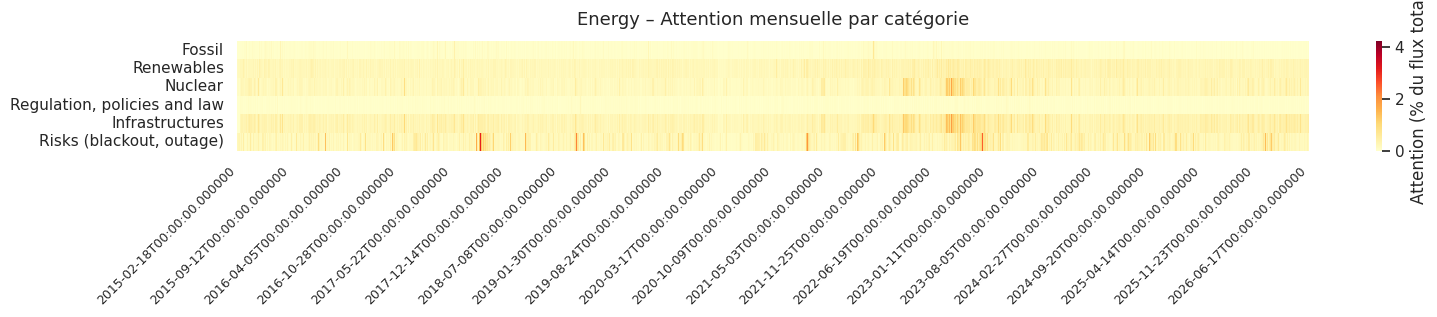

In [14]:
attn_cols = [c for c in indicators.columns if c.startswith("attention_")]
attn_df   = indicators[attn_cols].copy()
attn_df.columns = [c.replace(f"attention_{SECTOR_KEY}_", "") for c in attn_df.columns]

# Remplacer les clés par les labels lisibles
cat_labels = {k: v["label"] for k, v in categories.items()}
attn_df.rename(columns=cat_labels, inplace=True)

fig, ax = plt.subplots(figsize=(16, max(3, len(attn_df.columns) * 0.55)))
sns.heatmap(
    attn_df.T * 100,
    ax=ax,
    cmap="YlOrRd",
    linewidths=0,
    cbar_kws={"label": "Attention (% du flux total)"},
    xticklabels=max(1, len(attn_df) // 20),
)
ax.set_title(f"{sector_label} – Attention mensuelle par catégorie", fontsize=13, pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.tight_layout()
plt.show()

### 5.2 Attention & sentiment par catégorie (séries temporelles)

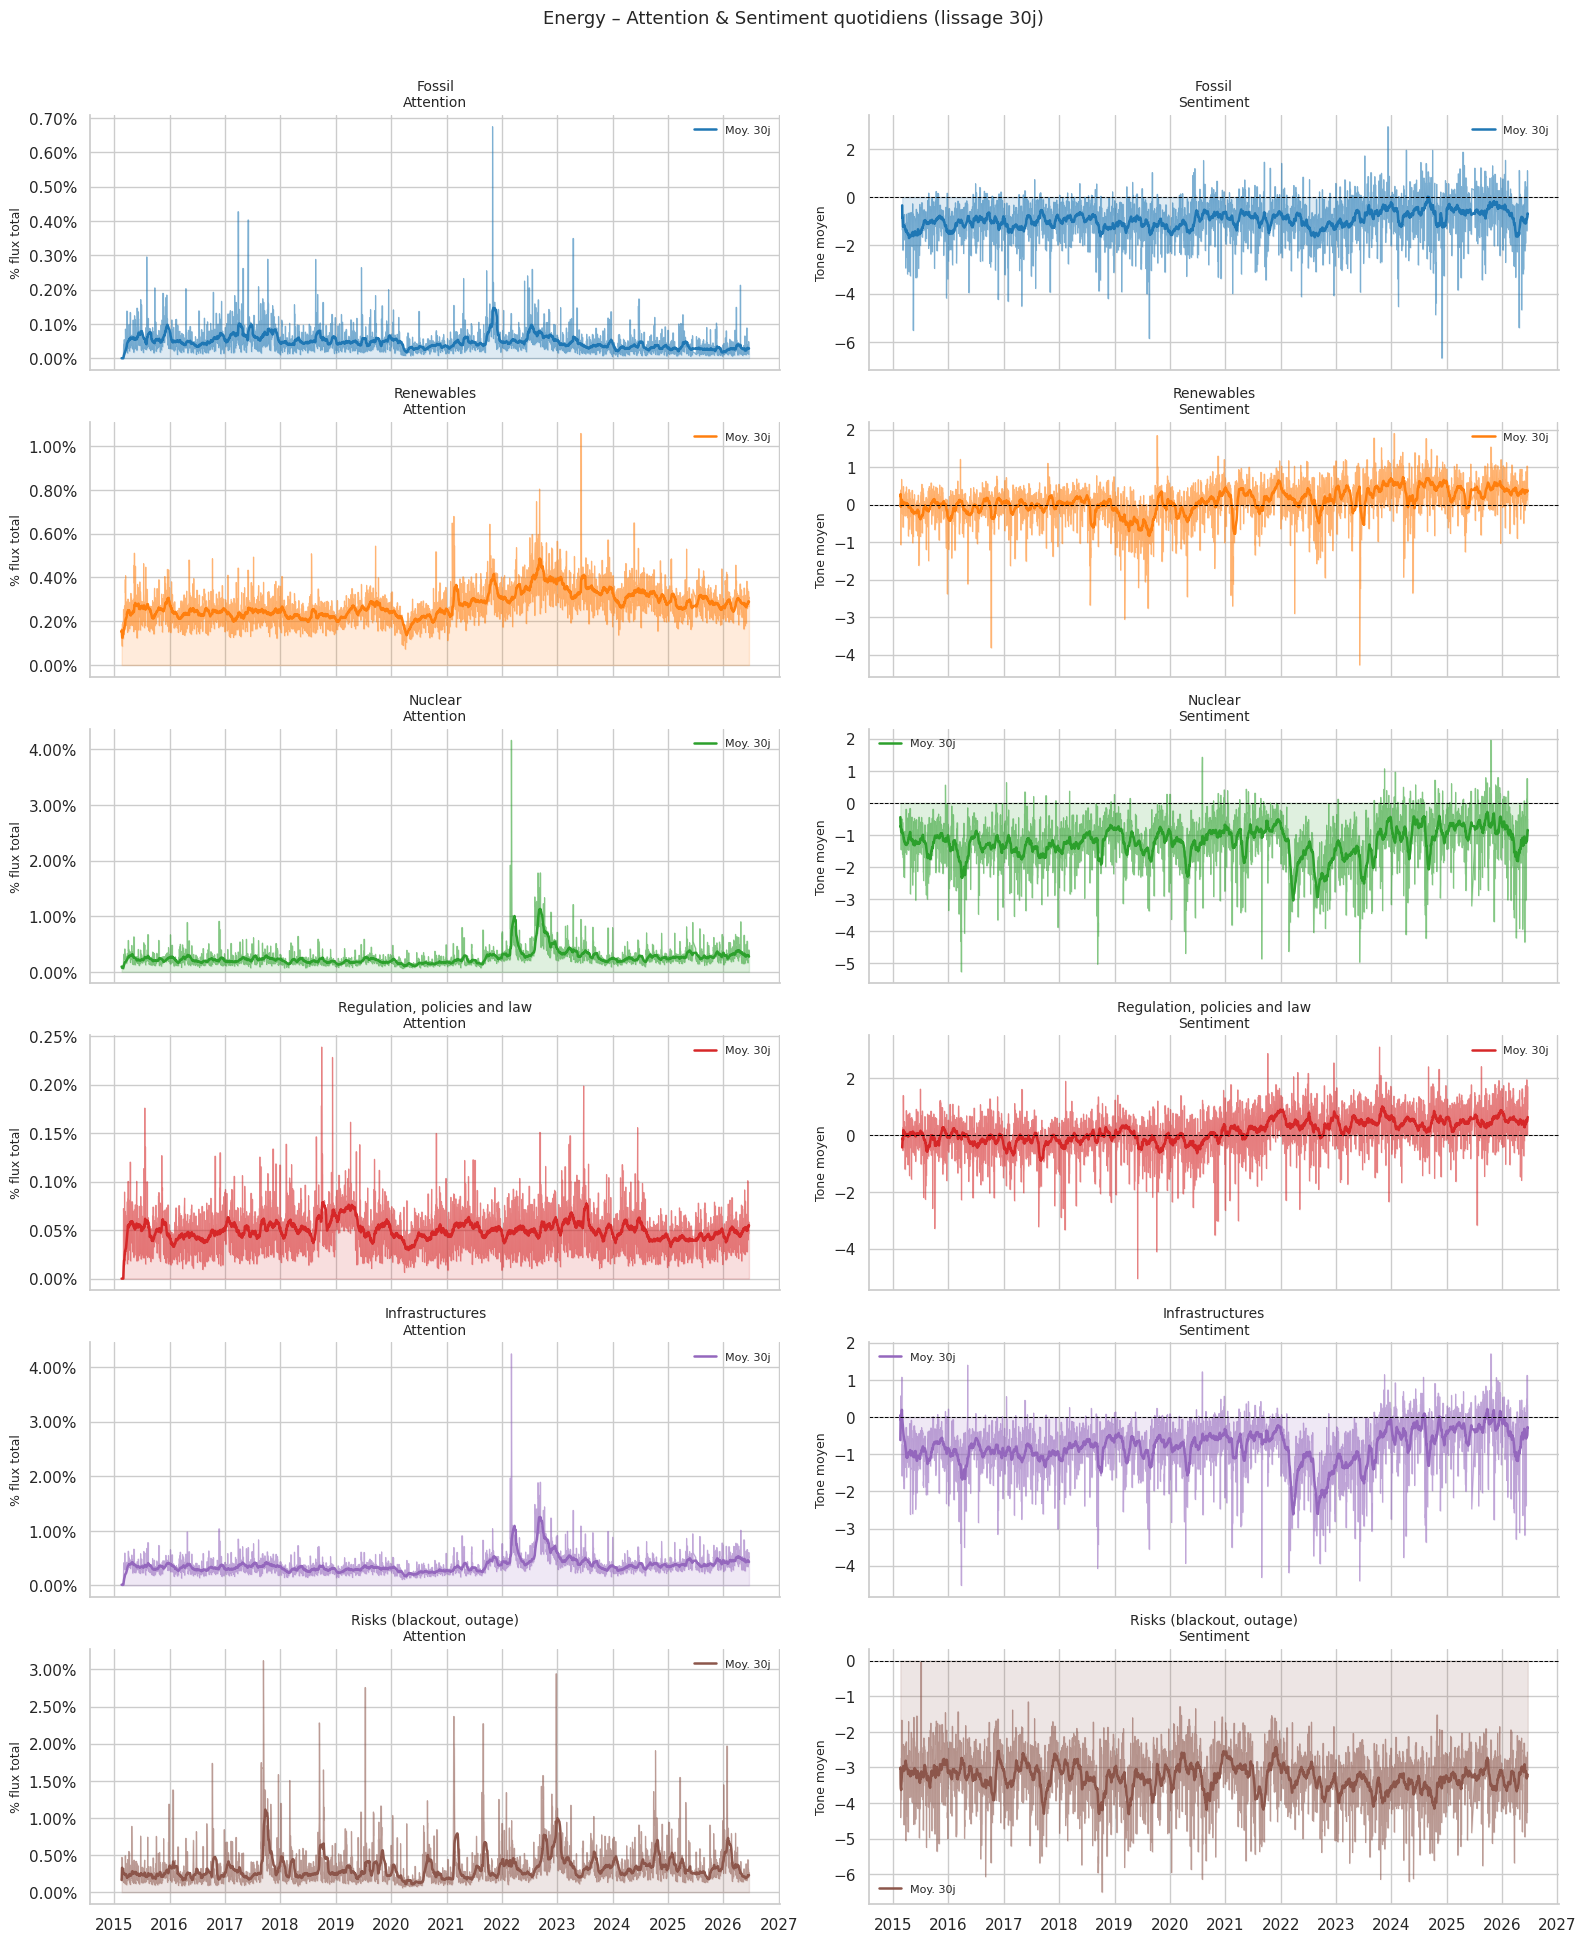

In [18]:
ROLLING = 30   # fenêtre de lissage en JOURS (moyenne mobile 1 mois)

cat_keys  = list(categories.keys())
n_cats    = len(cat_keys)
fig, axes = plt.subplots(n_cats, 2, figsize=(16, 3.2 * n_cats), sharex=True)

if n_cats == 1:
    axes = axes[np.newaxis, :]

for i, cat_key in enumerate(cat_keys):
    label   = categories[cat_key]["label"]
    color   = COLORS[i % len(COLORS)]

    # ── Récupération des données ──────────────────────────────────────────
    s_attn = indicators[f"attention_{SECTOR_KEY}_{cat_key}"]
    
    # LE CORRECTIF EST ICI : on force le type numérique pour que Matplotlib soit content
    s_sent = pd.to_numeric(indicators[f"sentiment_{SECTOR_KEY}_{cat_key}"], errors="coerce").dropna()

    # ── Attention ──────────────────────────────────────────────────────────
    ax_a = axes[i, 0]
    s_raw  = s_attn * 100
    s_roll = s_raw.rolling(ROLLING, min_periods=1).mean()

    ax_a.fill_between(indicators.index, s_raw, alpha=0.15, color=color)
    ax_a.plot(indicators.index, s_raw,  lw=0.8, alpha=0.5, color=color)
    ax_a.plot(indicators.index, s_roll, lw=1.8, color=color, label=f"Moy. {ROLLING}j")

    ax_a.set_ylabel("% flux total", fontsize=9)
    ax_a.set_title(f"{label}\nAttention", fontsize=10)
    ax_a.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.2f}%"))
    ax_a.legend(fontsize=8, frameon=False)

    # ── Sentiment ──────────────────────────────────────────────────────────
    ax_s = axes[i, 1]
    
    # On vérifie s'il reste des données après le dropna pour éviter un autre plantage
    if not s_sent.empty:
        s_roll_s = s_sent.rolling(ROLLING, min_periods=1).mean()

        ax_s.fill_between(s_sent.index, s_sent, alpha=0.15, color=color)
        ax_s.plot(s_sent.index, s_sent,   lw=0.8, alpha=0.5, color=color)
        ax_s.plot(s_roll_s.index, s_roll_s, lw=1.8, color=color, label=f"Moy. {ROLLING}j")
    
    ax_s.axhline(0, color="black", lw=0.7, ls="--")
    ax_s.set_ylabel("Tone moyen", fontsize=9)
    ax_s.set_title(f"{label}\nSentiment", fontsize=10)
    ax_s.legend(fontsize=8, frameon=False)

    for ax in [ax_a, ax_s]:
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.suptitle(f"{sector_label} – Attention & Sentiment quotidiens (lissage {ROLLING}j)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 5.3 Vue agrégée : attention totale du secteur vs sentiment moyen

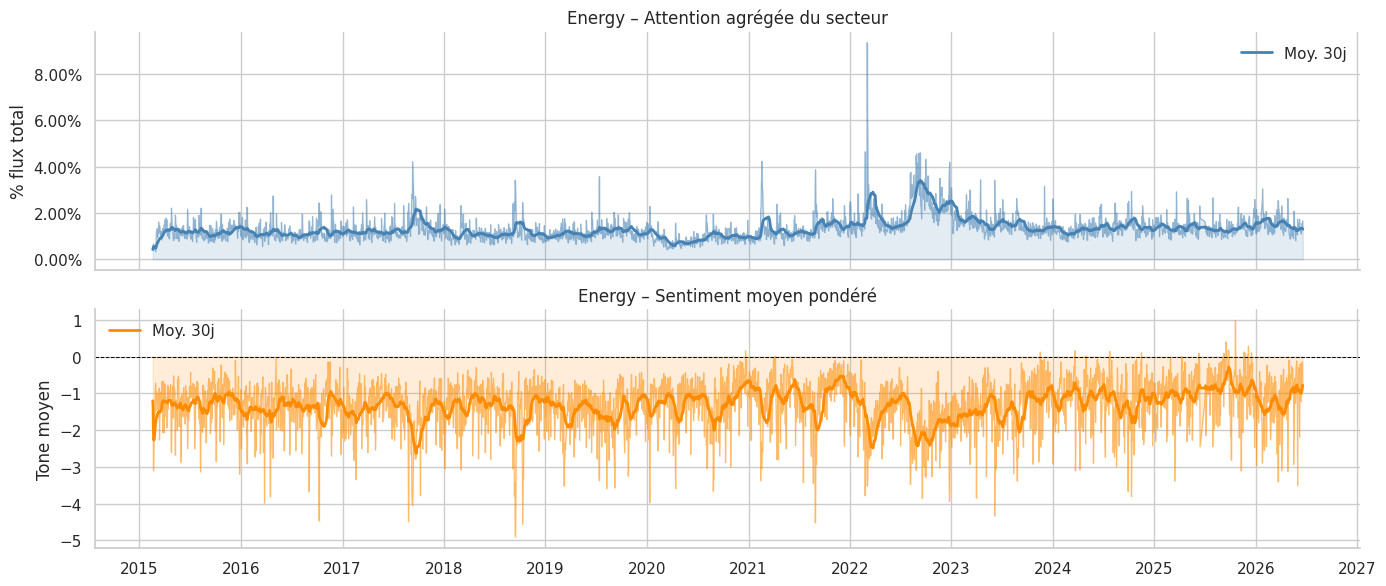

In [20]:
ROLLING = 30  # Lissage sur 30 jours (Moyenne mobile mensuelle)

# Attention totale du secteur = somme sur les catégories (volume normalisé)
vol_cols  = [c for c in indicators.columns if c.startswith("volume_")]
sent_cols = [c for c in indicators.columns if c.startswith("sentiment_")]

sector_vol  = indicators[vol_cols].sum(axis=1)

# On récupère le total des news proprement indexé sur la date
total_news  = total_news_df.set_index(pd.to_datetime(total_news_df["period"]))["total_news"]
sector_attn = (sector_vol / total_news).rename("sector_attention") * 100

# Sentiment moyen pondéré (par volume)
# On force le format numérique (pd.to_numeric) pour chaque colonne pour éviter l'erreur "isfinite"
s_num = sum(
    pd.to_numeric(indicators[f"sentiment_{SECTOR_KEY}_{k}"], errors="coerce").fillna(0)
    * pd.to_numeric(indicators[f"volume_{SECTOR_KEY}_{k}"], errors="coerce").fillna(0)
    for k in categories
)
s_den = indicators[vol_cols].sum(axis=1).replace(0, np.nan)

# LE CORRECTIF EST ICI : on force le résultat final en numérique et on retire les jours vides
sector_sent = pd.to_numeric((s_num / s_den), errors="coerce").rename("sector_sentiment").dropna()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Attention
roll_a = sector_attn.rolling(ROLLING, min_periods=1).mean()
ax1.fill_between(sector_attn.index, sector_attn, alpha=0.15, color="steelblue")
ax1.plot(sector_attn.index, sector_attn, lw=0.8, alpha=0.5, color="steelblue")
ax1.plot(roll_a.index, roll_a, lw=2, color="steelblue", label=f"Moy. {ROLLING}j")
ax1.set_ylabel("% flux total")
ax1.set_title(f"{sector_label} – Attention agrégée du secteur")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.2f}%"))
ax1.legend(frameon=False)

# Sentiment
# On vérifie qu'il y a bien des données de sentiment à afficher
if not sector_sent.empty:
    roll_s = sector_sent.rolling(ROLLING, min_periods=1).mean()
    ax2.fill_between(sector_sent.index, sector_sent, alpha=0.15, color="darkorange")
    ax2.plot(sector_sent.index, sector_sent, lw=0.8, alpha=0.5, color="darkorange")
    ax2.plot(roll_s.index, roll_s, lw=2, color="darkorange", label=f"Moy. {ROLLING}j")

ax2.axhline(0, color="black", lw=0.7, ls="--")
ax2.set_ylabel("Tone moyen")
ax2.set_title(f"{sector_label} – Sentiment moyen pondéré")
ax2.legend(frameon=False)

for ax in [ax1, ax2]:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

### 5.4 Corrélations entre catégories

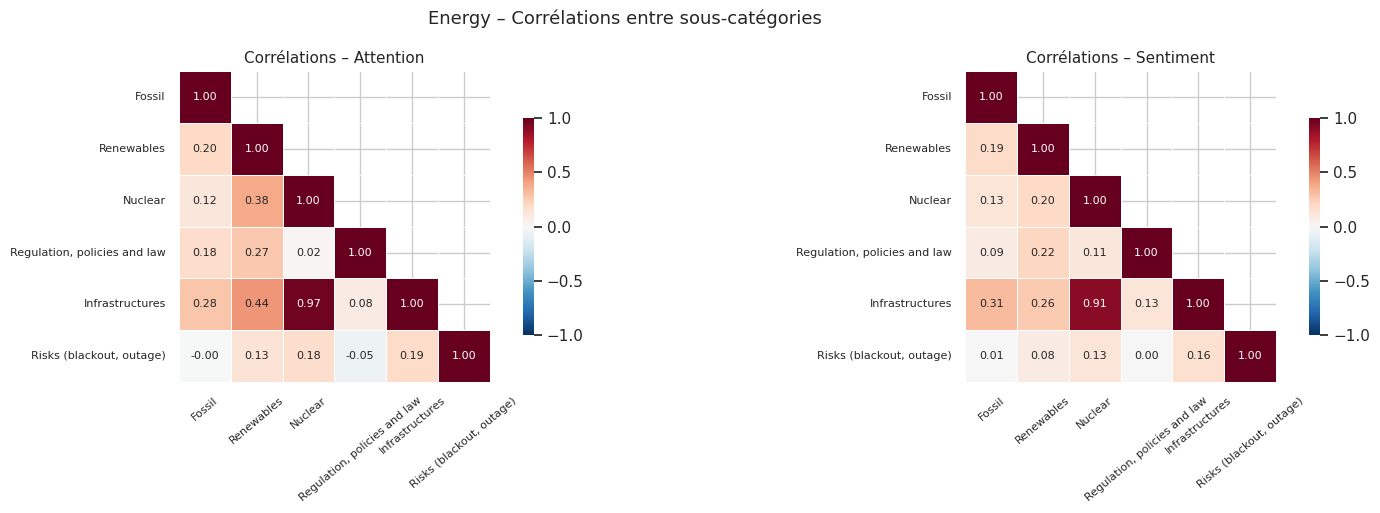

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(categories) * 0.7 + 1)))

short_labels = {k: v["label"][:28] for k, v in categories.items()}

for ax, metric, title in zip(
    axes,
    ["attention", "sentiment"],
    ["Attention", "Sentiment"]
):
    cols = [f"{metric}_{SECTOR_KEY}_{k}" for k in categories]
    
    # LE CORRECTIF EST ICI : on utilise apply(pd.to_numeric) pour nettoyer toutes les colonnes d'un coup
    corr = indicators[cols].apply(pd.to_numeric, errors='coerce').rename(
        columns={f"{metric}_{SECTOR_KEY}_{k}": short_labels[k] for k in categories}
    ).corr()

    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(
        corr, ax=ax, mask=mask,
        annot=True, fmt=".2f", annot_kws={"size": 8},
        cmap="RdBu_r", vmin=-1, vmax=1,
        square=True, linewidths=0.4,
        cbar_kws={"shrink": 0.7},
    )
    ax.set_title(f"Corrélations – {title}", fontsize=11)
    ax.tick_params(axis="x", rotation=40, labelsize=8)
    ax.tick_params(axis="y", rotation=0,  labelsize=8)

plt.suptitle(f"{sector_label} – Corrélations entre sous-catégories", fontsize=13)
plt.tight_layout()
plt.show()

### 5.5 Statistiques descriptives

In [28]:
rows = []
for cat_key, cat_cfg in categories.items():
    # NOUVEAU : On extrait les séries directement depuis le grand tableau 'indicators'
    s_a = indicators[f"attention_{SECTOR_KEY}_{cat_key}"] * 100
    
    # NOUVEAU : On force le numérique sur le sentiment pour éviter l'erreur TypeError
    s_s = pd.to_numeric(indicators[f"sentiment_{SECTOR_KEY}_{cat_key}"], errors="coerce").dropna()
    
    rows.append({
        "Catégorie"          : cat_cfg["label"],
        "Attention moy. (%)" : s_a.mean(),
        "Attention max. (%)" : s_a.max(),
        "Attention σ"        : s_a.std(),
        "Sentiment moy."     : s_s.mean(),
        "Sentiment σ"        : s_s.std(),
        "% jours positifs"   : (s_s > 0).mean() * 100, # J'ai changé "mois" par "jours" dans le label ;)
    })

stats_df = pd.DataFrame(rows).set_index("Catégorie")
display(
    stats_df.style
    .format({
        "Attention moy. (%)": "{:.3f}",
        "Attention max. (%)": "{:.3f}",
        "Attention σ"       : "{:.4f}",
        "Sentiment moy."    : "{:.3f}",
        "Sentiment σ"       : "{:.3f}",
        "% jours positifs"  : "{:.1f}%",
    })
    .background_gradient(cmap="YlOrRd", subset=["Attention moy. (%)", "Attention max. (%)"])
    .background_gradient(cmap="RdBu",   subset=["Sentiment moy."], vmin=-5, vmax=5)
    .set_caption(f"{sector_label} – Statistiques descriptives (toute la période)")
)

,Attention moy. (%),Attention max. (%),Attention σ,Sentiment moy.,Sentiment σ,% jours positifs
Catégorie,,,,,,
Fossil,0.047,0.675,0.0349,-0.941,0.794,8.8%
Renewables,0.276,1.058,0.0801,0.092,0.523,62.7%
Nuclear,0.256,4.166,0.1767,-1.236,0.781,2.9%
"Regulation, policies and law",0.050,0.239,0.0213,0.131,0.716,61.2%
Infrastructures,0.371,4.244,0.1859,-0.807,0.720,9.5%
"Risks (blackout, outage)",0.324,3.119,0.2553,-3.295,0.767,0.0%


⏳ Création des graphiques superposés (Design épuré)...


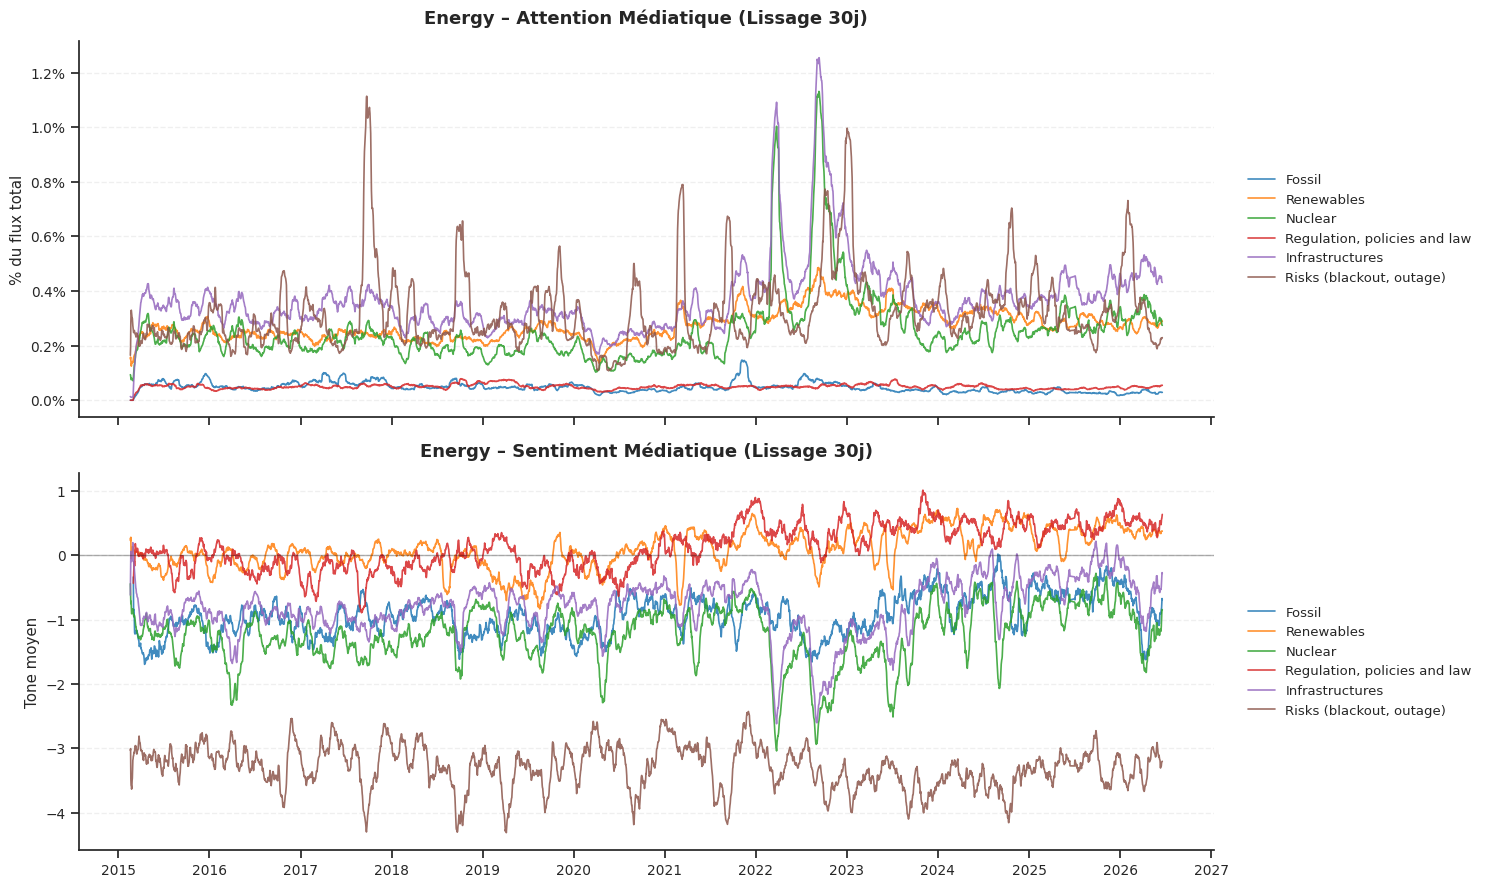

In [35]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import seaborn as sns

print("⏳ Création des graphiques superposés (Design épuré)...")

ROLLING = 30

# On force un thème très propre (fond blanc, pas de gris)
sns.set_theme(style="ticks", font_scale=0.9)

# Format plus panoramique (moins haut)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

for i, (cat_key, cat_cfg) in enumerate(categories.items()):
    label = cat_cfg["label"]
    color = COLORS[i % len(COLORS)]
    
    # ── 1. Traitement de l'Attention ──
    s_attn = indicators[f"attention_{SECTOR_KEY}_{cat_key}"] * 100
    s_attn_roll = s_attn.rolling(ROLLING, min_periods=1).mean()
    # Traits beaucoup plus fins (1.2) et légère transparence (0.85)
    ax1.plot(s_attn_roll.index, s_attn_roll, lw=1.2, alpha=0.85, color=color, label=label)
    
    # ── 2. Traitement du Sentiment ──
    s_sent = pd.to_numeric(indicators[f"sentiment_{SECTOR_KEY}_{cat_key}"], errors="coerce").dropna()
    if not s_sent.empty:
        s_sent_roll = s_sent.rolling(ROLLING, min_periods=1).mean()
        ax2.plot(s_sent_roll.index, s_sent_roll, lw=1.2, alpha=0.85, color=color, label=label)

# ── Esthétique Graphique 1 (Attention) ──
ax1.set_title(f"{sector_label} – Attention Médiatique (Lissage {ROLLING}j)", fontsize=13, fontweight="bold", pad=12)
ax1.set_ylabel("% du flux total")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.1f}%"))
ax1.grid(axis='y', linestyle='--', alpha=0.3) # Grille très subtile (horizontale uniquement)
ax1.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=9.5) # Légende sans cadre
sns.despine(ax=ax1) # Retire les bordures hautes et droites

# ── Esthétique Graphique 2 (Sentiment) ──
ax2.axhline(0, color="black", lw=1, ls="-", alpha=0.3) # Ligne de neutralité très discrète
ax2.set_title(f"{sector_label} – Sentiment Médiatique (Lissage {ROLLING}j)", fontsize=13, fontweight="bold", pad=12)
ax2.set_ylabel("Tone moyen")
ax2.grid(axis='y', linestyle='--', alpha=0.3)
ax2.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=9.5)
sns.despine(ax=ax2)

# ── Formatage de l'axe X (Dates partagées) ──
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.set_xlabel("") # On retire le label "period" inutile
plt.setp(ax2.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

⏳ Création du graphique d'Attention en Base 100...


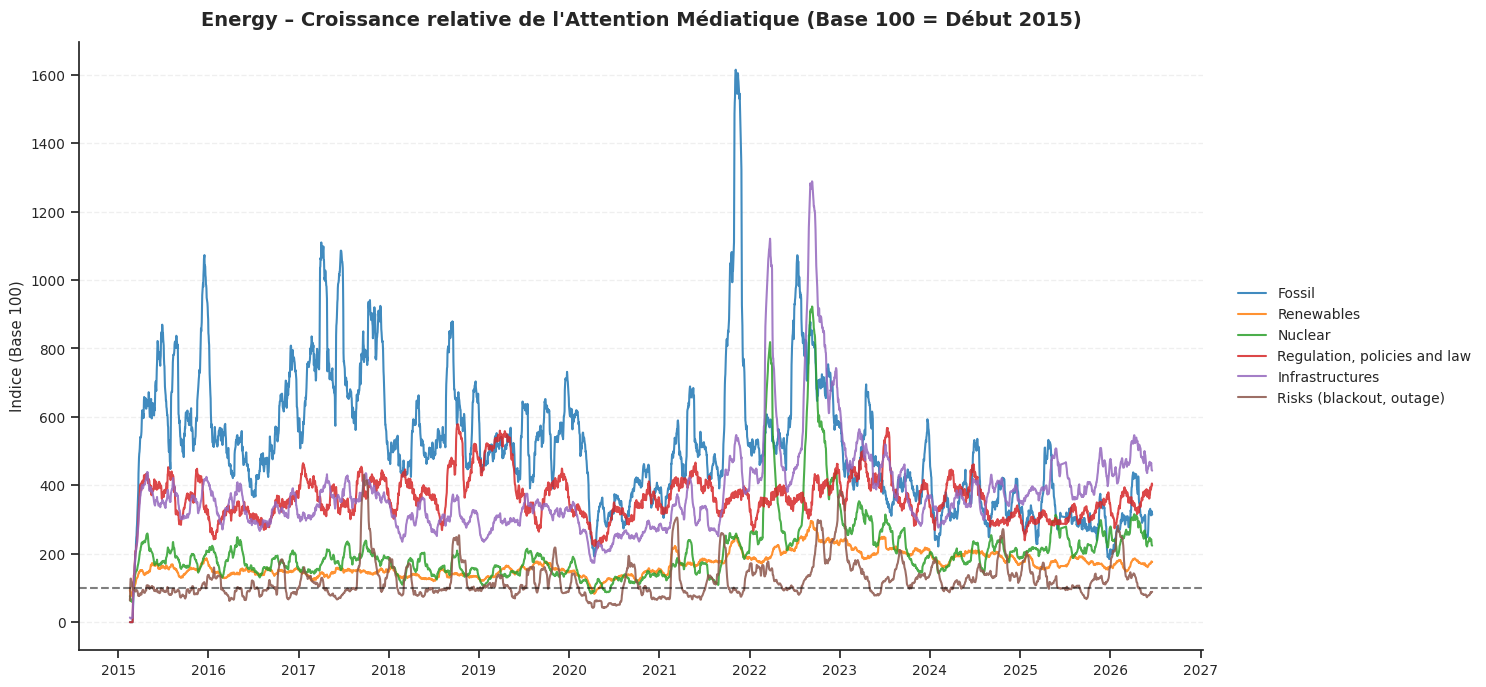

In [36]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import seaborn as sns

print("⏳ Création du graphique d'Attention en Base 100...")

ROLLING = 30

sns.set_theme(style="ticks", font_scale=0.9)
fig, ax1 = plt.subplots(figsize=(15, 7))

for i, (cat_key, cat_cfg) in enumerate(categories.items()):
    label = cat_cfg["label"]
    color = COLORS[i % len(COLORS)]
    
    # ── 1. Calcul de l'Attention et Lissage ──
    s_attn = indicators[f"attention_{SECTOR_KEY}_{cat_key}"] * 100
    s_attn_roll = s_attn.rolling(ROLLING, min_periods=1).mean()
    
    # ── 2. Conversion en Base 100 ──
    # On prend la moyenne des 30 premiers jours comme "référence 100" pour plus de robustesse
    valeur_ref = s_attn_roll.dropna().iloc[:30].mean()
    
    if valeur_ref > 0: # Sécurité anti division par zéro
        s_attn_base100 = (s_attn_roll / valeur_ref) * 100
        ax1.plot(s_attn_base100.index, s_attn_base100, lw=1.5, alpha=0.85, color=color, label=label)

# ── Esthétique ──
ax1.axhline(100, color="black", lw=1.5, ls="--", alpha=0.5) # Ligne de départ (Indice 100)
ax1.set_title(f"{sector_label} – Croissance relative de l'Attention Médiatique (Base 100 = Début 2015)", fontsize=14, fontweight="bold", pad=12)
ax1.set_ylabel("Indice (Base 100)")

ax1.grid(axis='y', linestyle='--', alpha=0.3)
ax1.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=10)
sns.despine(ax=ax1)

# ── Formatage de l'axe X ──
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.set_xlabel("")

plt.tight_layout()
plt.show()

⏳ Téléchargement des données financières depuis Yahoo Finance...


[*********************100%***********************]  2 of 2 completed


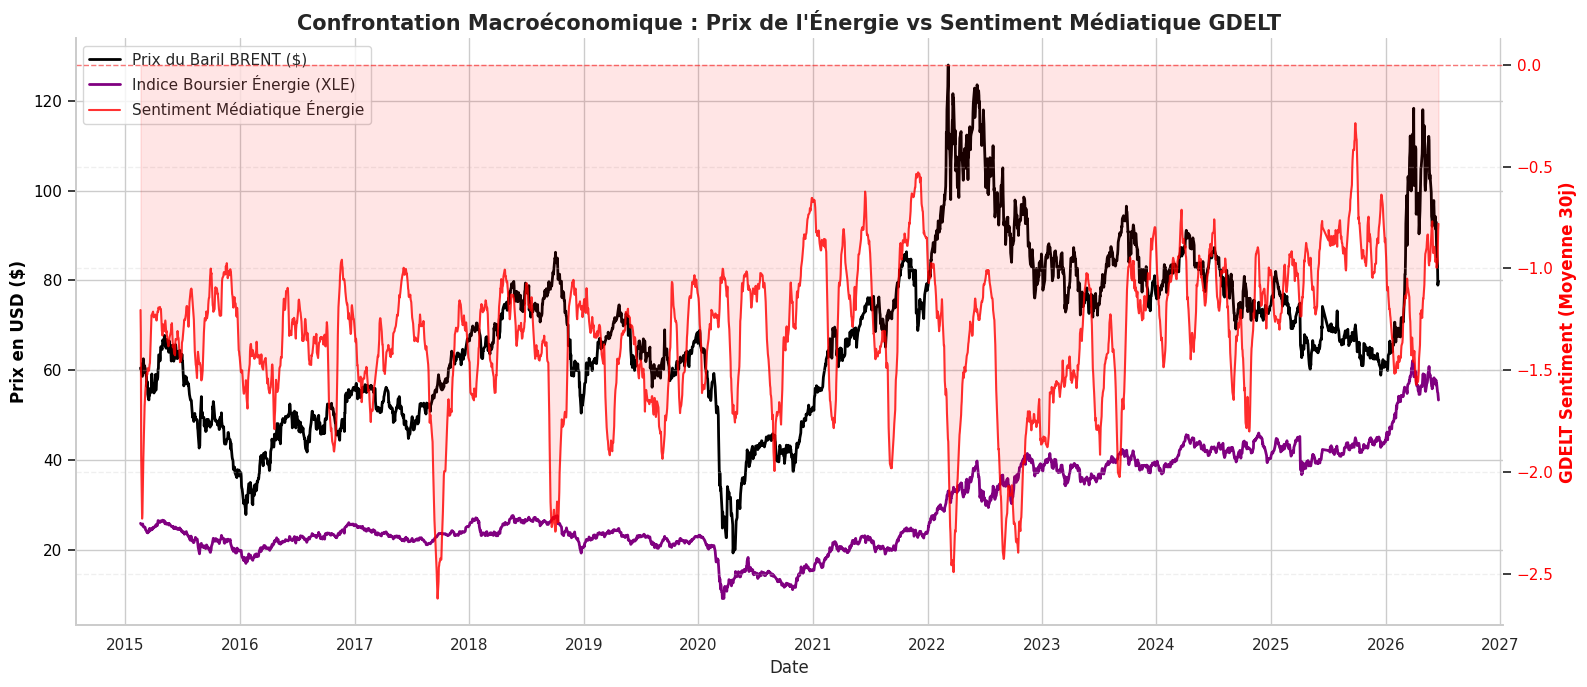


📊 Matrice de corrélation de Pearson (Relation mathématique) :


,BRENT_Price,XLE_Index,GDELT_Sentiment,GDELT_Attention
BRENT_Price,1.00,0.68,-0.08,0.57
XLE_Index,0.68,1.00,0.13,0.43
GDELT_Sentiment,-0.08,0.13,1.00,-0.52
GDELT_Attention,0.57,0.43,-0.52,1.00


In [30]:
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("⏳ Téléchargement des données financières depuis Yahoo Finance...")

# 1. On définit la période de téléchargement calquée sur tes données GDELT
start_date = indicators.index.min().strftime('%Y-%m-%d')
end_date = indicators.index.max().strftime('%Y-%m-%d')

# Téléchargement du Brent (BZ=F) et de l'ETF Energie mondial (XLE)
tickers = "BZ=F XLE"
finance_data = yf.download(tickers, start=start_date, end=end_date)["Close"]

# 2. Nettoyage et fusion des calendriers
# GDELT tourne 7j/7, la bourse 5j/7. On fait une jointure interne (Inner Join)
# pour ne garder que les jours où la bourse était ouverte, ce qui permet des calculs propres.
df_finance = finance_data.dropna()

# On récupère le sentiment et l'attention lissés sur 30 jours pour ne pas comparer du bruit à des prix
sector_sent_30 = sector_sent.rolling(30, min_periods=1).mean()
sector_attn_30 = sector_attn.rolling(30, min_periods=1).mean()

# On assemble tout dans un seul DataFrame pandas
df_macro = pd.DataFrame({
    "BRENT_Price": df_finance["BZ=F"],
    "XLE_Index": df_finance["XLE"],
    "GDELT_Sentiment": sector_sent_30,
    "GDELT_Attention": sector_attn_30
}).dropna() # Supprime les jours sans cotation

# 3. Création du graphique à double échelle (Dual Axis)
fig, ax1 = plt.subplots(figsize=(16, 7))

# AXE DE GAUCHE : Finance (Prix en $)
color_brent = "black"
color_xle = "purple"
ax1.set_xlabel("Date")
ax1.set_ylabel("Prix en USD ($)", color=color_brent, fontweight="bold")
line1 = ax1.plot(df_macro.index, df_macro["BRENT_Price"], color=color_brent, lw=2, label="Prix du Baril BRENT ($)")
line2 = ax1.plot(df_macro.index, df_macro["XLE_Index"], color=color_xle, lw=2, label="Indice Boursier Énergie (XLE)")
ax1.tick_params(axis='y', labelcolor=color_brent)

# AXE DE DROITE : GDELT (Sentiment)
ax2 = ax1.twinx()  # Instancie un second axe Y qui partage le même axe X
color_gdelt = "red"
ax2.set_ylabel("GDELT Sentiment (Moyenne 30j)", color=color_gdelt, fontweight="bold")
# On trace la courbe de sentiment. On la remplit de couleur rouge quand c'est négatif
line3 = ax2.plot(df_macro.index, df_macro["GDELT_Sentiment"], color=color_gdelt, lw=1.5, alpha=0.8, label="Sentiment Médiatique Énergie")
ax2.fill_between(df_macro.index, df_macro["GDELT_Sentiment"], 0, where=(df_macro["GDELT_Sentiment"] < 0), color=color_gdelt, alpha=0.1)
ax2.axhline(0, color=color_gdelt, linestyle="--", lw=1, alpha=0.5)
ax2.tick_params(axis='y', labelcolor=color_gdelt)

# Rassembler les légendes des deux axes
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left", frameon=True)

plt.title("Confrontation Macroéconomique : Prix de l'Énergie vs Sentiment Médiatique GDELT", fontsize=15, fontweight="bold")

# Formatage des dates
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Affichage de la matrice de corrélation
print("\n📊 Matrice de corrélation de Pearson (Relation mathématique) :")
display(df_macro.corr().style.background_gradient(cmap="coolwarm", vmin=-1, vmax=1).format("{:.2f}"))

⏳ Recalcul des cross-corrélations sur les VARIATIONS (Momentum)...


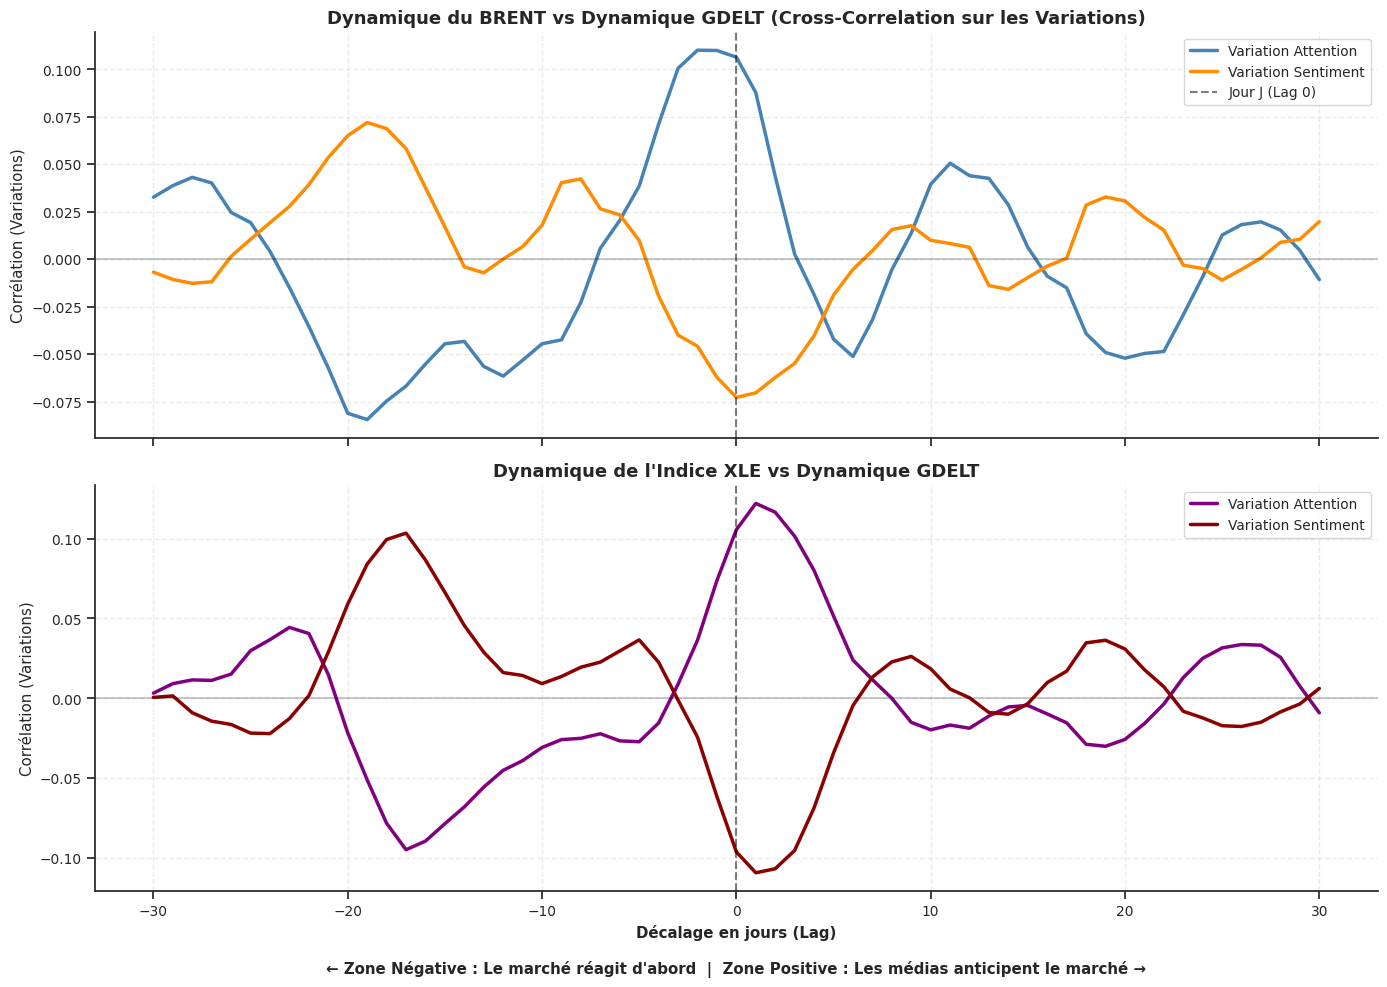


🏆 MEILLEURS DÉCALAGES SUR LES VARIATIONS (Puissance prédictive maximale) :
- Attention vs BRENT : Corrélation max de 0.11 atteinte à Lag -2 jours (Réaction (Bourse en avance))
- Sentiment vs BRENT : Corrélation max de -0.07 atteinte à Lag 0 jours (Synchrone)
- Attention vs XLE : Corrélation max de 0.12 atteinte à Lag 1 jours (Anticipation (Médias en avance))
- Sentiment vs XLE : Corrélation max de -0.11 atteinte à Lag 1 jours (Anticipation (Médias en avance))


In [39]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

print("⏳ Recalcul des cross-corrélations sur les VARIATIONS (Momentum)...")

# 1. On repart des données brutes (ou lissées sur 7j max pour le bruit, pas 30j !)
df_macro_fast = pd.DataFrame({
    "BRENT_Price": df_finance["BZ=F"],
    "XLE_Index": df_finance["XLE"],
    "GDELT_Sentiment": sector_sent.rolling(7, min_periods=1).mean(),
    "GDELT_Attention": sector_attn.rolling(7, min_periods=1).mean()
}).dropna()

# 2. LE SECRET : On calcule la variation (Différence sur 5 jours de bourse = 1 semaine)
# On regarde la dynamique ("Est-ce que ça monte ?") et non le niveau ("Est-ce que c'est haut ?")
df_var = df_macro_fast.diff(5).dropna()

# Plage des décalages en jours
lags = range(-30, 31)
correlations = {
    "Attention vs BRENT": [],
    "Sentiment vs BRENT": [],
    "Attention vs XLE": [],
    "Sentiment vs XLE": []
}

# 3. Calcul des corrélations sur les variations
for lag in lags:
    shifted_attn = df_var["GDELT_Attention"].shift(lag)
    shifted_sent = df_var["GDELT_Sentiment"].shift(lag)
    
    correlations["Attention vs BRENT"].append(df_var["BRENT_Price"].corr(shifted_attn))
    correlations["Sentiment vs BRENT"].append(df_var["BRENT_Price"].corr(shifted_sent))
    correlations["Attention vs XLE"].append(df_var["XLE_Index"].corr(shifted_attn))
    correlations["Sentiment vs XLE"].append(df_var["XLE_Index"].corr(shifted_sent))

df_lags = pd.DataFrame(correlations, index=lags)

# ── Création du graphique ──
sns.set_theme(style="ticks", font_scale=0.9)
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# 1. BRENT
axes[0].plot(df_lags.index, df_lags["Attention vs BRENT"], label="Variation Attention", color="steelblue", lw=2.5)
axes[0].plot(df_lags.index, df_lags["Sentiment vs BRENT"], label="Variation Sentiment", color="darkorange", lw=2.5)
axes[0].axvline(0, color="black", linestyle="--", alpha=0.5, label="Jour J (Lag 0)")
axes[0].axhline(0, color="black", linestyle="-", alpha=0.2)
axes[0].set_title("Dynamique du BRENT vs Dynamique GDELT (Cross-Correlation sur les Variations)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Corrélation (Variations)")
axes[0].legend(loc="upper right")
axes[0].grid(True, linestyle="--", alpha=0.4)
sns.despine(ax=axes[0])

# 2. XLE
axes[1].plot(df_lags.index, df_lags["Attention vs XLE"], label="Variation Attention", color="purple", lw=2.5)
axes[1].plot(df_lags.index, df_lags["Sentiment vs XLE"], label="Variation Sentiment", color="darkred", lw=2.5)
axes[1].axvline(0, color="black", linestyle="--", alpha=0.5)
axes[1].axhline(0, color="black", linestyle="-", alpha=0.2)
axes[1].set_title("Dynamique de l'Indice XLE vs Dynamique GDELT", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Décalage en jours (Lag)\n\n← Zone Négative : Le marché réagit d'abord  |  Zone Positive : Les médias anticipent le marché →", fontweight="bold")
axes[1].set_ylabel("Corrélation (Variations)")
axes[1].legend(loc="upper right")
axes[1].grid(True, linestyle="--", alpha=0.4)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

# ── Affichage automatique des meilleurs décalages ──
print("\n🏆 MEILLEURS DÉCALAGES SUR LES VARIATIONS (Puissance prédictive maximale) :")
for col in df_lags.columns:
    best_lag = df_lags[col].abs().idxmax()
    best_corr = df_lags[col].loc[best_lag]
    
    sens = "Anticipation (Médias en avance)" if best_lag > 0 else ("Réaction (Bourse en avance)" if best_lag < 0 else "Synchrone")
    print(f"- {col} : Corrélation max de {best_corr:.2f} atteinte à Lag {best_lag} jours ({sens})")

⏳ Analyse des régimes de volatilité déclenchés par l'attention extrême...


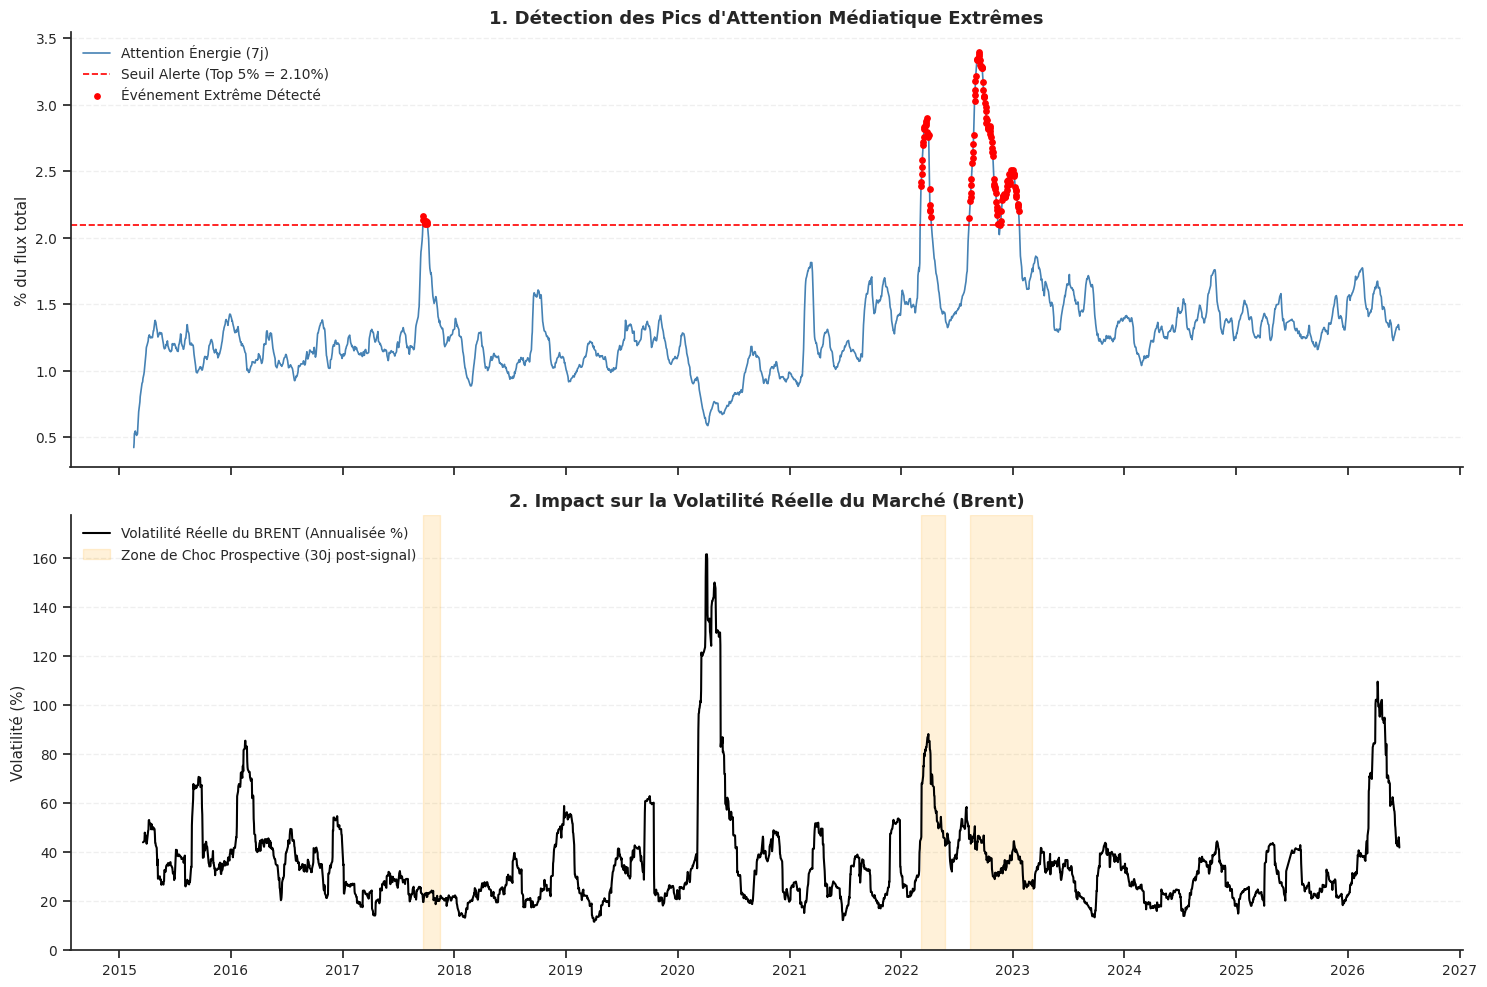


📊 --- VERDICT SCIENTIFIQUE SUR LA PUISSANCE PRÉDICTIVE ---
- Nombre total de chocs médiatiques majeurs détectés : 142 jours
- Volatilité moyenne en période CALME : 35.00 %
- Volatilité moyenne durant les 30j APRÈS un pic média : 40.68 %
- Prime de risque d'attention (Surcroît de volatilité) : +5.67 %

🔥 CONCLUSION : Ton indicateur fonctionne ! Les pics d'attention anticipent une hausse significative de la nervosité des marchés sur les 30 jours suivants.


In [42]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import seaborn as sns

print("⏳ Analyse des régimes de volatilité déclenchés par l'attention extrême...")

# 1. Préparation des données financières (Calcul des rendements et de la volatilité)
# Rendement quotidien (Pourcentage de variation)
df_macro["BRENT_Return"] = df_macro["BRENT_Price"].pct_change()

# Volatilité historique glissante sur 22 jours de bourse (~1 mois)
# Annualisée (multipliée par la racine de 252 jours de bourse par an) et passée en %
df_macro["BRENT_Volatility"] = df_macro["BRENT_Return"].rolling(22).std() * np.sqrt(252) * 100

# 2. Définition du Seuil d'Attention Extrême
# Au lieu d'un chiffre arbitraire, on prend le 95ème percentile (le top 5% des plus gros pics d'actualité)
ATTN_THRESHOLD = df_macro["GDELT_Attention"].quantile(0.95)

# Déclenchement du signal (True/False)
df_macro["Is_Extreme_Event"] = df_macro["GDELT_Attention"] > ATTN_THRESHOLD

# 3. Création de la fenêtre prospective de 30 jours (Forward Window)
# Si un événement a lieu au jour J, les jours J+1 à J+30 sont classés en "Zone de Choc"
df_macro["In_Choc_Zone"] = (
    df_macro["Is_Extreme_Event"]
    .shift(1)                  # On décale de 1 jour pour commencer APRÈS le signal
    .rolling(30, min_periods=1)# On propage le signal sur 30 jours de bourse
    .max()                     # Si au moins un signal a eu lieu dans les 30j, renvoie 1
    .fillna(0)
    .astype(bool)
)

# 4. TRACÉ DU COCKPIT DE VOLATILITÉ
sns.set_theme(style="ticks", font_scale=0.9)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Graphique 1 : L'Attention GDELT et les déclencheurs
ax1.plot(df_macro.index, df_macro["GDELT_Attention"], color="steelblue", lw=1.2, label="Attention Énergie (7j)")
ax1.axhline(ATTN_THRESHOLD, color="red", linestyle="--", lw=1.2, label=f"Seuil Alerte (Top 5% = {ATTN_THRESHOLD:.2f}%)")

# On marque par des points rouges les jours de franchissement du seuil
signals = df_macro[df_macro["Is_Extreme_Event"]]
ax1.scatter(signals.index, signals["GDELT_Attention"], color="red", s=15, zorder=5, label="Événement Extrême Détecté")

ax1.set_title("1. Détection des Pics d'Attention Médiatique Extrêmes", fontsize=13, fontweight="bold")
ax1.set_ylabel("% du flux total")
ax1.legend(loc="upper left", frameon=False)
ax1.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine(ax=ax1)

# Graphique 2 : La volatilité du marché et les zones de choc prédictives
ax2.plot(df_macro.index, df_macro["BRENT_Volatility"], color="black", lw=1.5, label="Volatilité Réelle du BRENT (Annualisée %)")

# On incruste les zones de chocs en arrière-plan (couleur orange transparente)
# On utilise une astuce matplotlib pour masquer les blocs continus
in_choc = df_macro["In_Choc_Zone"]
ax2.fill_between(df_macro.index, 0, df_macro["BRENT_Volatility"].max() * 1.1, 
                 where=in_choc, color="orange", alpha=0.15, label="Zone de Choc Prospective (30j post-signal)")

ax2.set_title("2. Impact sur la Volatilité Réelle du Marché (Brent)", fontsize=13, fontweight="bold")
ax2.set_ylabel("Volatilité (%)")
ax2.set_ylim(0, df_macro["BRENT_Volatility"].max() * 1.1)
ax2.legend(loc="upper left", frameon=False)
ax2.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine(ax=ax2)

# Formatage de l'axe temporel
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.set_xlabel("")

plt.tight_layout()
plt.show()

# 5. LE VERDICT STATISTIQUE
vol_normal = df_macro[~df_macro["In_Choc_Zone"]]["BRENT_Volatility"].mean()
vol_choc = df_macro[df_macro["In_Choc_Zone"]]["BRENT_Volatility"].mean()
prime_vol = vol_choc - vol_normal

print("\n📊 --- VERDICT SCIENTIFIQUE SUR LA PUISSANCE PRÉDICTIVE ---")
print(f"- Nombre total de chocs médiatiques majeurs détectés : {signals['Is_Extreme_Event'].sum()} jours")
print(f"- Volatilité moyenne en période CALME : {vol_normal:.2f} %")
print(f"- Volatilité moyenne durant les 30j APRÈS un pic média : {vol_choc:.2f} %")
print(f"- Prime de risque d'attention (Surcroît de volatilité) : {prime_vol:+.2f} %")

if prime_vol > 2:
    print("\n🔥 CONCLUSION : Ton indicateur fonctionne ! Les pics d'attention anticipent "
          "une hausse significative de la nervosité des marchés sur les 30 jours suivants.")
else:
    print("\n🧊 CONCLUSION : L'effet de l'attention sur la volatilité n'est pas marqué sur cette période.")

In [3]:
!pip install pandas_datareader --quiet
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import pandas as pd

print("⏳ Téléchargement de l'inflation (FRED)...")

# Codes FRED : 
# 'CPIAUCSL' = US Consumer Price Index (All items)
# 'CP0000EZ19M086NEST' = Euro Area HICP (Harmonised Index of Consumer Prices)
start_date = "2015-01-01"
inflation_codes = {
    'Inflation_US': 'CPIAUCSL',
    'Inflation_UE': 'CP0000EZ19M086NEST'
}

# Téléchargement
df_infl = web.DataReader(list(inflation_codes.values()), 'fred', start=start_date)
df_infl = df_infl.rename(columns={v: k for k, v in inflation_codes.items()})

# 1. Calcul du taux de variation annuel (YOY - Year over Year)
# Le CPI est un indice, pour avoir l'inflation en %, on fait : ((Indice_t / Indice_t-12) - 1) * 100
df_infl_yoy = df_infl.pct_change(12) * 100

# 2. Conversion en fréquence quotidienne (Upsampling)
# On ré-échantillonne en jours pour matcher avec tes données GDELT
df_infl_daily = df_infl_yoy.resample('D').interpolate(method='linear').dropna()

# 3. Fusion avec ton DataFrame macro existant
# On fait un 'left join' pour garder tes dates GDELT en priorité
df_macro_infl = df_macro.join(df_infl_daily, how='left')

# Visualisation rapide
fig, ax1 = plt.subplots(figsize=(15, 6))

ax1.plot(df_macro_infl.index, df_macro_infl['Inflation_US'], color='blue', label='Inflation US (YOY %)')
ax1.plot(df_macro_infl.index, df_macro_infl['Inflation_UE'], color='green', label='Inflation UE (YOY %)')
ax1.set_ylabel("Taux d'inflation annuel (%)")
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(df_macro_infl.index, df_macro_infl['GDELT_Attention'], color='red', alpha=0.3, label='Attention Énergie')
ax2.set_ylabel("Attention Médiatique")
ax2.legend(loc='upper right')

plt.title("Comparaison : Inflation Officielle vs Attention Médiatique Énergie")
plt.show()

⏳ Téléchargement de l'inflation (FRED)...


NameError: name 'df_macro' is not defined

In [4]:
print(f"Nombre de points de données inflation US : {df_infl['Inflation_US'].count()}")
print(f"Nombre de points de données inflation UE : {df_infl['Inflation_UE'].count()}")

Nombre de points de données inflation US : 136
Nombre de points de données inflation UE : 137


## 6. Export

In [ ]:
out_path = Path(f"./{SECTOR_KEY}_indicators.parquet")
indicators.to_parquet(out_path)
print(f"Indicateurs sauvegardés → {out_path}")
print(f"Dimensions : {indicators.shape[0]} périodes × {indicators.shape[1]} colonnes")
indicators.tail(3)